Illustration for constructing a dendrogram using the segment-DTW approach.

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from joblib import load
from seismicif.dtw import segment_dtw
from seismicif.datamod.loading_utils import preproc_flow_annotations, read_segment

In [7]:
folder = "../data/XP/2018/ILL11/HHZ.D/"
stream_paths = [folder + f for f in os.listdir(folder) if not f.startswith("._")]
stream_paths = np.array(sorted(stream_paths, key=lambda f: int(f.rsplit(".", 1)[-1])))

if_mod = load("../output/if_models/ILL11_illustration.joblib")

if_segments = preproc_flow_annotations(
    pd.read_csv("../output/if_segments/ILL11_illustration.csv", index_col=0)
)

In [8]:
dist_matrix = np.zeros([if_segments.shape[0], if_segments.shape[0]])

In [9]:
try:
    dist_matrix = np.load("../output/dtw_pairwise/dist_matrix.npy")

except (FileNotFoundError, OSError):
    for i in range(dist_matrix.shape[0]):
        seg1 = read_segment(
            if_segments["start"][i], if_segments["stop"][i], stream_paths
        )
        for j in range(dist_matrix.shape[0]):
            if i >= j:
                continue

            if dist_matrix[i, j] > 0:
                continue

            seg2 = read_segment(
                if_segments["start"][j], if_segments["stop"][j], stream_paths
            )
            dist_matrix[i, j] = np.median(segment_dtw(seg1, seg2, if_mod))

    np.save("../output/dtw_pairwise/dist_matrix.npy", dist_matrix)

dist_matrix = dist_matrix + dist_matrix.T

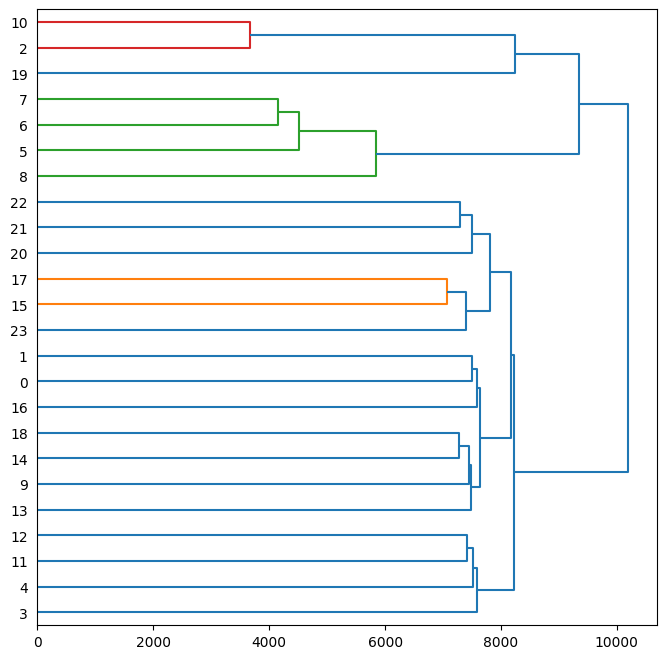

In [ ]:
D = squareform(dist_matrix)
Z = linkage(squareform(dist_matrix), method="complete")
plt.figure(figsize=(8, 8))
dendrogram(Z, orientation="right")
plt.show()